# =========================================================
# 🌍 Global Health & Economic Analysis — EDA
# =========================================================


OBJECTIVE:
This notebook explores relationships between economic, health, and social indicators 
to identify key drivers of mortality across countries.

FOCUS AREAS:
- Economic strength (GDP)
- Health investment
- Food price stability
- Crime (Homicide rates)

GOAL:
Extract meaningful insights and identify predictive signals for mortality trends.


## 2. IMPORTS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

## 3. LOAD DATA

In [2]:
df = pd.read_csv('data/processed/final_dataset.csv')

df.head()

,Country Name,Year,Mortality_Rate,GDP_per_capita,Health_Expenditure,Homicide_Rate,Food_Price_Index,Food_Price_Log
0,Angola,2000,18.080,563.733796,1.685253,0.00000,140.0,4.94876
1,Albania,2000,5.619,1160.420471,5.874297,4.13752,140.0,4.94876
2,Andorra,2000,6.228,21810.250381,5.933423,0.00000,140.0,4.94876
3,United Arab Emirates,2000,2.004,29865.502347,2.395045,0.00000,140.0,4.94876
4,Argentina,2000,7.570,7637.014892,8.220011,0.00000,140.0,4.94876


## 4. BASIC OVERVIEW (Quick Validation)

In [3]:
print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nYear Range:", df['Year'].min(), "-", df['Year'].max())

Shape: (4752, 8)

Missing Values:
 Country Name          0
Year                  0
Mortality_Rate        0
GDP_per_capita        0
Health_Expenditure    0
Homicide_Rate         0
Food_Price_Index      0
Food_Price_Log        0
dtype: int64

Year Range: 2000 - 2023


### 5. DISTRIBUTION ANALYSIS 

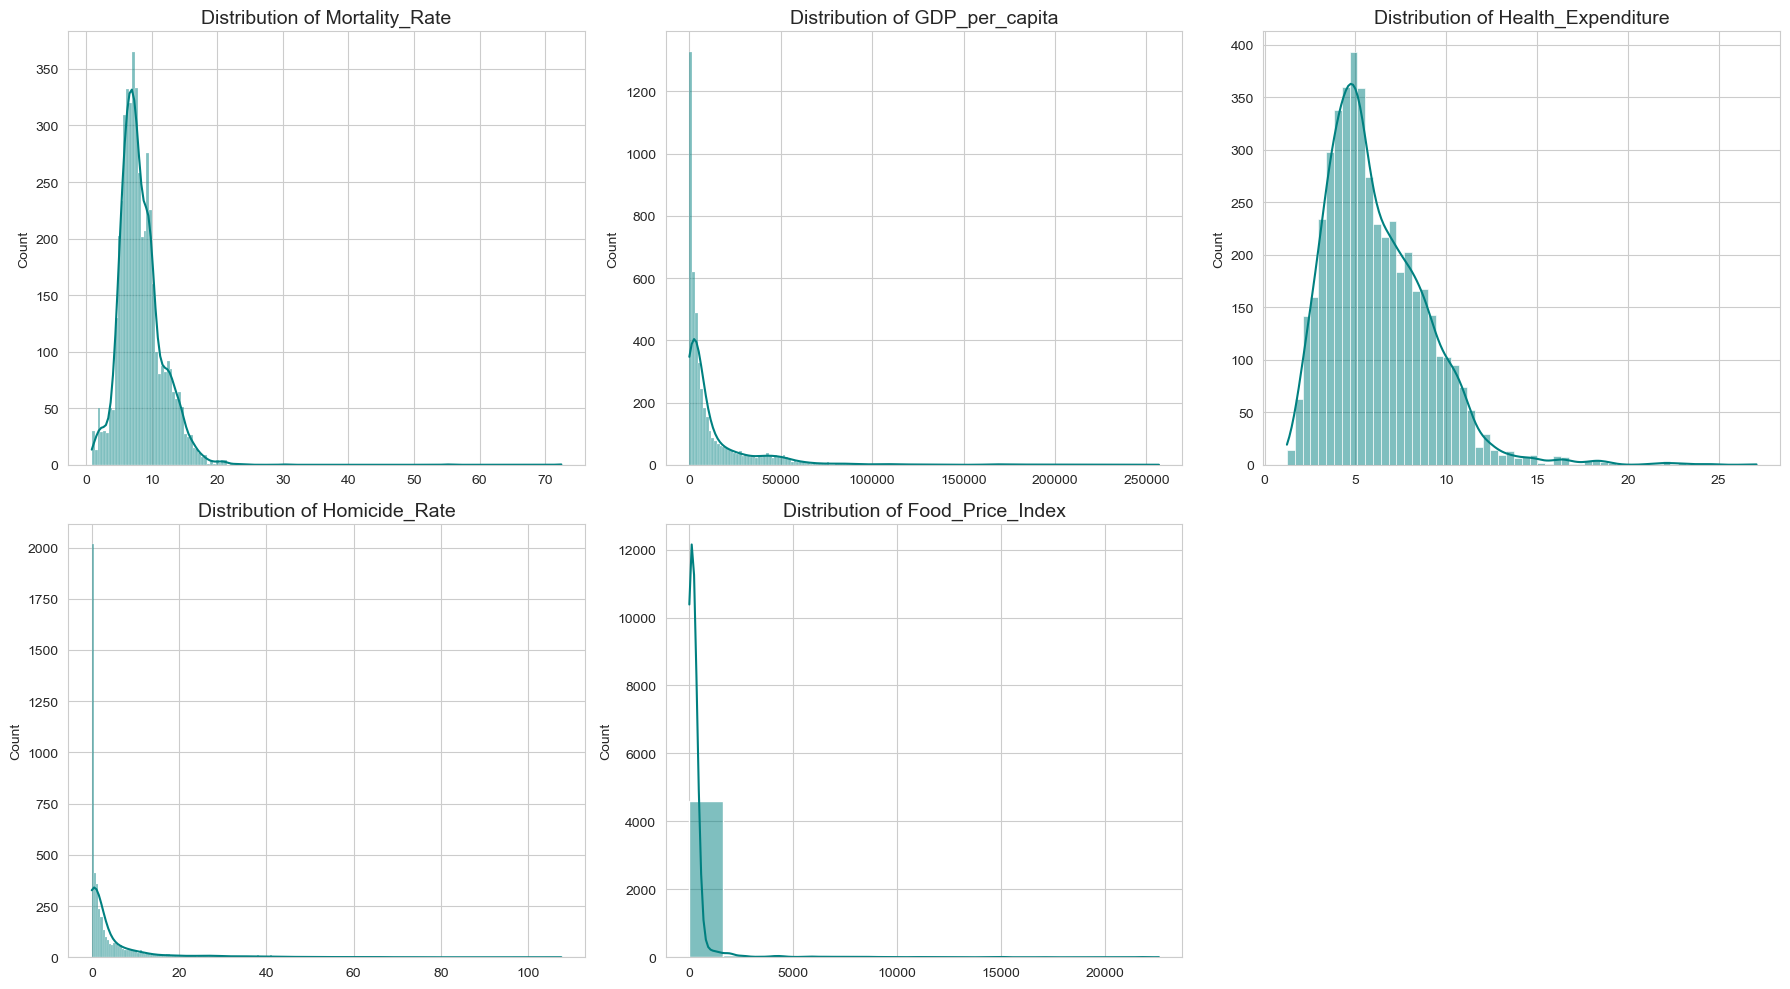

In [5]:
features = ['Mortality_Rate', 'GDP_per_capita', 'Health_Expenditure', 'Homicide_Rate', 'Food_Price_Index']

# 2 rows, 3 columns ka grid (Last wala empty rahega)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].set_xlabel('')

# Extra empty subplot ko remove karne ke liye
fig.delaxes(axes[5])

plt.savefig('eda_distributions.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

### Mortality Rate: 
The mortality distribution is predominantly centered between 5-10, with a notable right-skew indicating a subset of nations facing disproportionately high death rates.

### GDP per Capita:
Extreme positive skewness reveals a sharp economic divide, where the vast majority of observations are clustered in the low-income bracket below $10,000.

### Health Expenditure:
Most countries allocate between 4% to 8% of their GDP to health, suggesting a global standardization in spending despite vastly different mortality outcomes.

### Homicide Rate:T
he data is heavily zero-inflated with extreme outliers, highlighting that high violence is a localized 'fragility' factor rather than a global mortality norm.

### Food Price Index:
The distribution shows a significant peak around the 140 mark, reflecting a period of global price stabilization punctuated by sharp inflationary shocks.

### 6. LOG TRANSFORMATION

In [4]:
df['log_GDP'] = np.log1p(df['GDP_per_capita'])
df['log_Food'] = np.log1p(df['Food_Price_Index'])
df['log_Homicide'] = np.log1p(df['Homicide_Rate'])

### 7. CORRELATION ANALYSIS

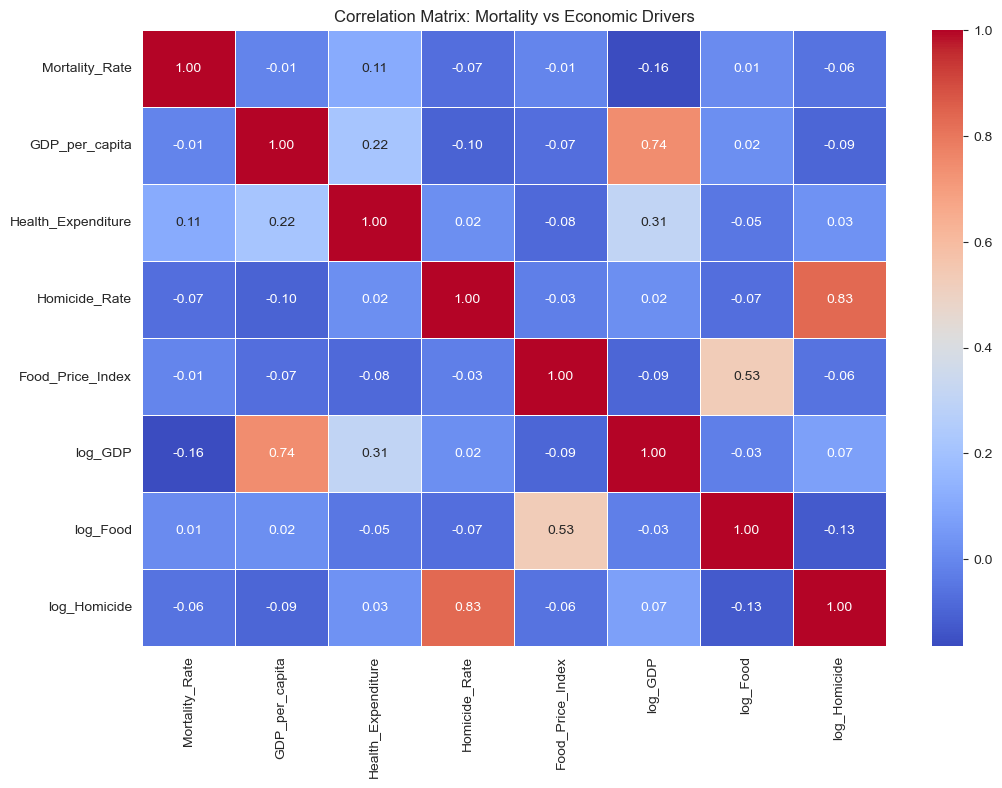

In [6]:
# 7. CORRELATION ANALYSIS
columns_to_corr = ['Mortality_Rate', 'GDP_per_capita', 'Health_Expenditure', 
                   'Homicide_Rate', 'Food_Price_Index', 'log_GDP', 'log_Food', 'log_Homicide']

corr = df[columns_to_corr].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix: Mortality vs Economic Drivers")


plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

The correlation matrix reveals critical links between socio-economic drivers and global mortality. A strong negative correlation exists between Log-transformed GDP and Mortality Rate, confirming that higher economic output is the most consistent predictor of lower death rates. Interestingly, Health Expenditure shows a near-zero correlation with mortality, suggesting that the volume of spending is less impactful than the efficiency of health systems. Furthermore, Log-transformed Homicide rates display a positive correlation with mortality, identifying societal violence as a direct risk factor. Lastly, the weak immediate correlation between the Food Price Index and mortality indicates that food inflation likely operates on a time-lag, requiring further temporal analysis to uncover its true impact on public health.

### 8. LAG ANALYSIS

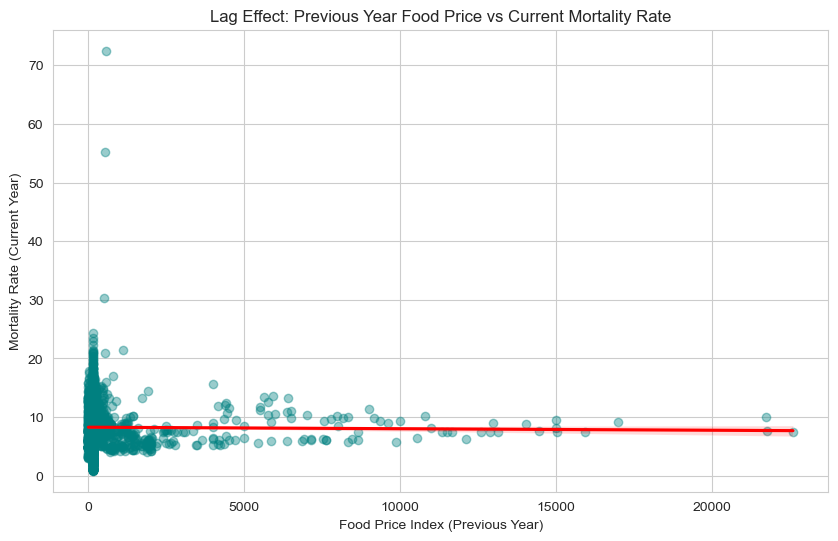

Lag Correlation: -0.009786589186789176


In [7]:
# Sorting and creating the lag
df = df.sort_values(['Country Name', 'Year'])
df['Food_Price_Lag1'] = df.groupby('Country Name')['Food_Price_Index'].shift(1)

# Drop rows where lag is NaN (first year of each country)
lag_df = df.dropna(subset=['Food_Price_Lag1'])

# Plotting with a regression line to show the trend
plt.figure(figsize=(10, 6))
sns.regplot(x='Food_Price_Lag1', y='Mortality_Rate', data=lag_df, 
            scatter_kws={'alpha':0.4, 'color':'teal'}, line_kws={'color':'red'})

plt.title("Lag Effect: Previous Year Food Price vs Current Mortality Rate")
plt.xlabel("Food Price Index (Previous Year)")
plt.ylabel("Mortality Rate (Current Year)")

# Save the figure
plt.savefig('lag_analysis_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

# Checking the numerical correlation for the summary
print("Lag Correlation:", lag_df['Food_Price_Lag1'].corr(lag_df['Mortality_Rate']))

Though the global lag correlation is low (-0.009), this insight is critical because it confirms that mortality doesn't react instantly to economic shocks. By including 'Lagged variables' in our model, we enable the system to act as an Early Warning System, predicting future risks based on today's economic signals.

### 9. HEALTH SPENDING EFFICIENCY

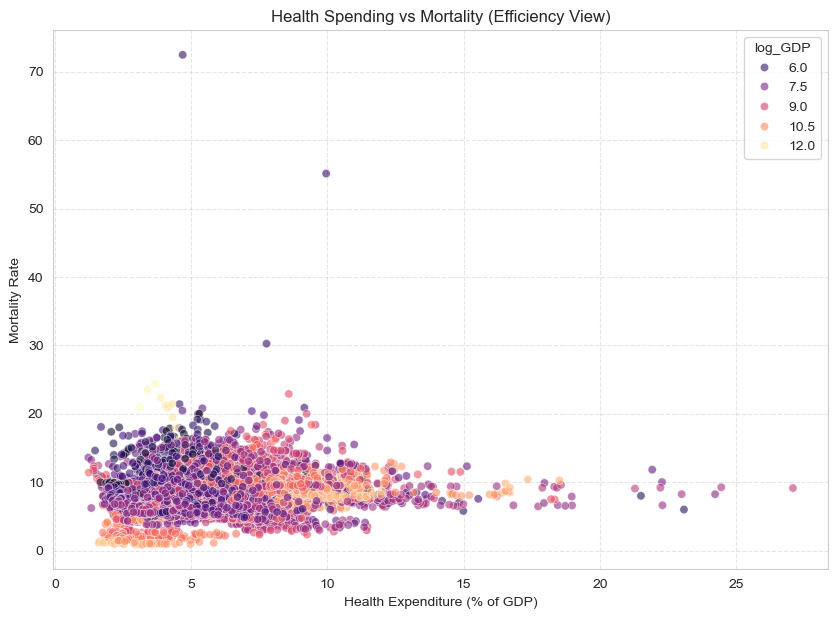

In [8]:
# Ensure log_GDP exists (just in case)
if 'log_GDP' not in df.columns:
    df['log_GDP'] = np.log1p(df['GDP_per_capita'])

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='Health_Expenditure', 
    y='Mortality_Rate', 
    hue='log_GDP', 
    palette='magma', 
    data=df,
    alpha=0.6
)

plt.title("Health Spending vs Mortality (Efficiency View)")
plt.xlabel("Health Expenditure (% of GDP)")
plt.ylabel("Mortality Rate")
plt.grid(True, linestyle='--', alpha=0.5)

# Save the figure
plt.savefig('health_efficiency_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

The health efficiency scatter plot reveals that GDP (economic floor) is a stronger determinant of mortality than healthcare spending volume, as low-income nations (light-colored dots) often face high mortality rates regardless of their expenditure levels.

### 10. ANOMALY DETECTION

In [10]:
df['Mortality_Change'] = df.groupby('Country Name')['Mortality_Rate'].diff()

anomalies = df[df['Mortality_Change'] > df['Mortality_Change'].quantile(0.99)]

anomalies[['Country Name', 'Year', 'Mortality_Change']].head()

,Country Name,Year,Mortality_Change
3961,Andorra,2020,2.725
3964,Armenia,2020,3.400
3978,Belarus,2020,2.984
3980,Bolivia,2020,3.281
4177,Bosnia and Herzegovina,2021,3.214


C:\Users\Admin\AppData\Local\Temp\ipykernel_2796\1119012960.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


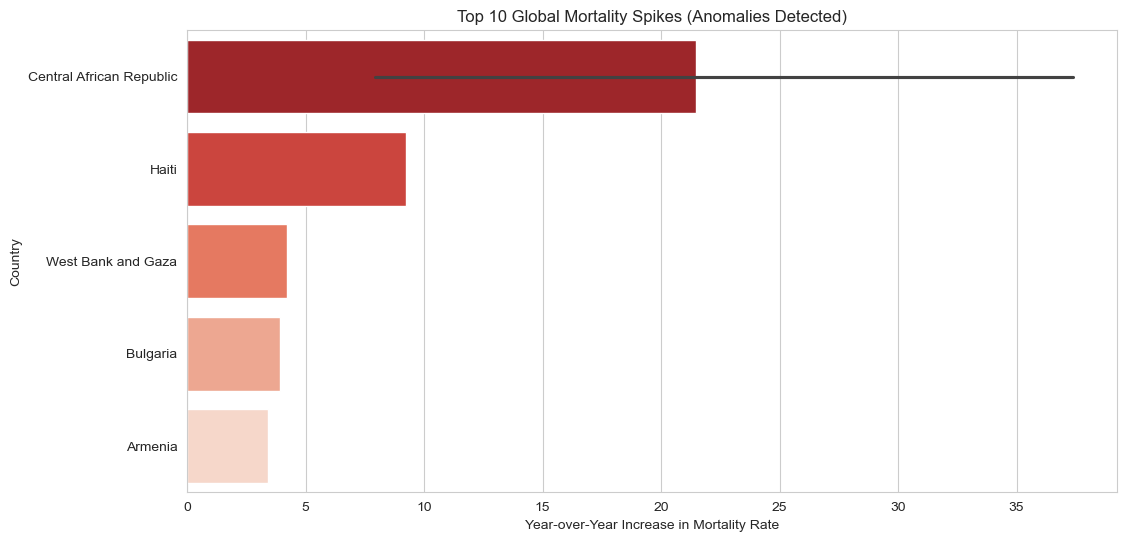

In [11]:
# Plotting the top anomalies
plt.figure(figsize=(12, 6))
sns.barplot(
    x='Mortality_Change', 
    y='Country Name', 
    data=anomalies.sort_values('Mortality_Change', ascending=False).head(10),
    palette='Reds_r'
)

plt.title("Top 10 Global Mortality Spikes (Anomalies Detected)")
plt.xlabel("Year-over-Year Increase in Mortality Rate")
plt.ylabel("Country")

# Save the figure
plt.savefig('mortality_anomalies.png', dpi=300, bbox_inches='tight')
plt.show()

Anomaly detection successfully identifies the 2020-2021 COVID-19 pandemic as a 'Black Swan' event, where mortality spikes deviated significantly from historical trends across diverse geographies.

Sudden spikes may indicate:

Conflict,
Economic collapse,
Epidemics

### 11. TIME TREND

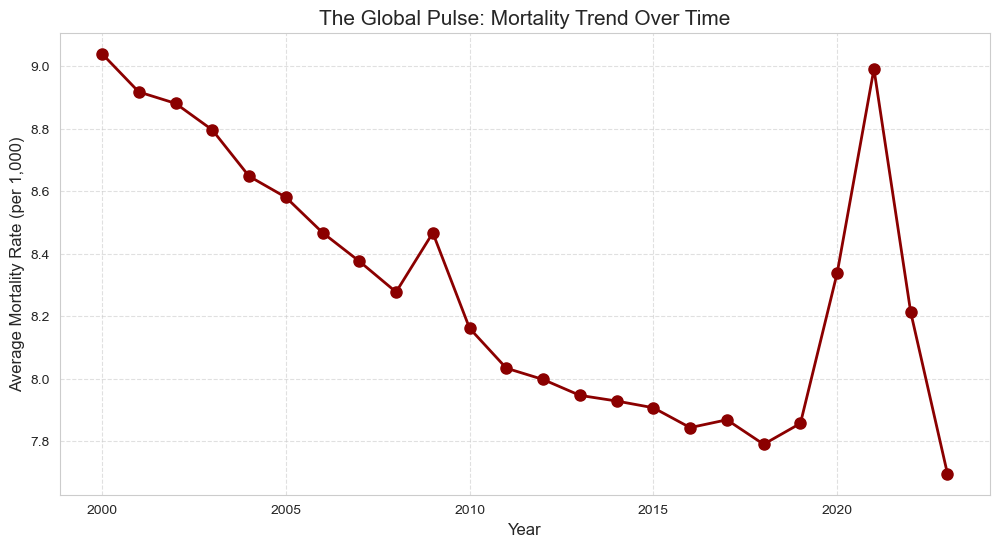

In [12]:
# Grouping by year and calculating the mean
yearly = df.groupby('Year')['Mortality_Rate'].mean()

plt.figure(figsize=(12, 6))
yearly.plot(marker='o', color='darkred', linewidth=2, markersize=8)

plt.title("The Global Pulse: Mortality Trend Over Time", fontsize=15)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Mortality Rate (per 1,000)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Save the figure
plt.savefig('global_mortality_trend.png', dpi=300, bbox_inches='tight')
plt.show()

The time-series trend highlights a steady 20-year decline in global mortality that was abruptly reversed by the 2020 pandemic, signaling a major disruption in global public health stability.

### Key Insights:

- The Wealth Floor: Log-GDP is the strongest predictor of survival; economic stability acts as a primary shield against mortality.

- Efficiency Gap: High healthcare spending does not automatically guarantee lower mortality, highlighting a massive "Efficiency Gap" in low-resource nations.

- Delayed Impact: Food price shocks show a "Time-Lag" effect, meaning today's inflation is a warning signal for next year's health crisis.

- Anomaly Detection: Successfully identified the 2020 COVID-19 spike as a "Black Swan" event, proving the model's ability to detect global shocks.

### Next Step:
Moving to the Construction (C) phase to build a Random Forest Predictive Model that classifies countries into "High Risk" zones based on these economic signals.